# Clasificador de Bayes

El objetivo es predecir quien dijo el mensaje (Mariana o Raúl) a partir del clasificador de Bayes y regresión logística.

#### Bibliotecas

In [94]:
#General
import numpy as np
import pandas as pd
from scipy.stats import uniform

#Manejo de texto plano
import re
import emoji
import unicodedata

#Graficas
import matplotlib.pyplot as plt
import seaborn as sns

#Nube de palabras
from wordcloud import WordCloud, STOPWORDS

#Analisis de texto
import spacy
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer

#Modelo de regresion logistica y Bayes
from sklearn.preprocessing import MinMaxScaler
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

#Busqueda de hiper-parametros, train test, metricas
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score, train_test_split
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score, roc_curve, confusion_matrix, make_scorer

#### Global options

In [2]:
np.random.seed(1989)

In [3]:
pd.options.display.float_format = '{:,.3f}'.format

In [4]:
#Modelo Spacy en español
nlp = spacy.load("es_core_news_lg")

In [5]:
#Cargamos las stopwords
stop_words = nlp.Defaults.stop_words

In [6]:
for word in nlp.Defaults.stop_words:
    nlp.vocab[word].is_stop = True

In [7]:
stop_words

{'a',
 'acuerdo',
 'adelante',
 'ademas',
 'además',
 'afirmó',
 'agregó',
 'ahi',
 'ahora',
 'ahí',
 'al',
 'algo',
 'alguna',
 'algunas',
 'alguno',
 'algunos',
 'algún',
 'alli',
 'allí',
 'alrededor',
 'ambos',
 'ante',
 'anterior',
 'antes',
 'apenas',
 'aproximadamente',
 'aquel',
 'aquella',
 'aquellas',
 'aquello',
 'aquellos',
 'aqui',
 'aquél',
 'aquélla',
 'aquéllas',
 'aquéllos',
 'aquí',
 'arriba',
 'aseguró',
 'asi',
 'así',
 'atras',
 'aun',
 'aunque',
 'añadió',
 'aún',
 'bajo',
 'bastante',
 'bien',
 'breve',
 'buen',
 'buena',
 'buenas',
 'bueno',
 'buenos',
 'cada',
 'casi',
 'cierta',
 'ciertas',
 'cierto',
 'ciertos',
 'cinco',
 'claro',
 'comentó',
 'como',
 'con',
 'conmigo',
 'conocer',
 'conseguimos',
 'conseguir',
 'considera',
 'consideró',
 'consigo',
 'consigue',
 'consiguen',
 'consigues',
 'contigo',
 'contra',
 'creo',
 'cual',
 'cuales',
 'cualquier',
 'cuando',
 'cuanta',
 'cuantas',
 'cuanto',
 'cuantos',
 'cuatro',
 'cuenta',
 'cuál',
 'cuáles',
 'cu

## Procesamiento de los datos

In [8]:
# Lista para almacenar los datos extraídos
data = []

# Expresiones regulares para apoyarnos con la selección de texto
pattern = r'(\d{1,2}/\d{1,2}/\d{4}), (\d{1,2}:\d{2}\s[ap]\. m\.) - (.*?): (.*)'

In [9]:
# Leer el archivo de texto línea por línea
with open("C:/Users/raulb/Desktop/Diplomado/Modulo2/Datos/chat_mariana.txt", 'r', encoding='utf-8') as archivo:
    for linea in archivo:
        match = re.match(pattern, linea.strip())
        if match:
            fecha = match.group(1)
            hora = match.group(2)
            emisor = match.group(3)
            mensaje = match.group(4)
            data.append([fecha, hora, emisor, mensaje])
        else:
            # Para manejar los casos donde el mensaje se continúa en la siguiente línea
            if data:
                data[-1][3] += ' ' + linea.strip()

In [10]:
datos = pd.DataFrame(data, columns=['Fecha', 'Hora', 'Emisor', 'Mensaje'])

In [11]:
datos.sample(10)

,Fecha,Hora,Emisor,Mensaje
349,31/7/2023,10:12 p. m.,Mariana 🖤,<Multimedia omitido>
19981,17/5/2024,11:34 a. m.,Mariana 🖤,Uyy puede serrr
88607,22/7/2025,7:52 p. m.,Raul Benez,Que mata a un albatros
14215,1/4/2024,11:00 a. m.,Mariana 🖤,Sin duda yo si soy mala
5196,12/10/2023,10:04 p. m.,Mariana 🖤,Jajaja qué onda
63839,22/1/2025,11:11 p. m.,Mariana 🖤,Ves! Ya lo había olvidado
32785,31/7/2024,4:33 p. m.,Raul Benez,ese?
22683,7/6/2024,4:03 p. m.,Mariana 🖤,Lo que nunca pasa
55342,20/11/2024,5:34 p. m.,Mariana 🖤,<Multimedia omitido>
69282,4/3/2025,10:34 a. m.,Raul Benez,Estoy a nada de decirle que que culpa tengo yo...


In [12]:
datos["Emisor"].value_counts(normalize = True)

Emisor
Raul Benez   0.533
Mariana 🖤    0.467
Name: proportion, dtype: float64

In [13]:
#Aplicamos la transformacion a 0 y 1 del emisor
datos['Emisor'] = datos['Emisor'].apply(lambda x: 0 if 'Raul' in x else 1)

In [14]:
print(f"Tamaño de los datos: {datos.shape}")

Tamaño de los datos: (100333, 4)


Tenemos 4 variables: Fecha, hora, Emisor y Mensaje. 

Vamos a estandarizar la variable Mensaje, eliminando las líneas que indican \<Multimedia omitido\>, así como quitar emojis. 

La variable Emisor será reemplazada por 0 y 1, 0 si el mensaje es de Raúl y 1 si es de Mariana.

In [15]:
#Eliminamos <Multimedia omitido>
datos = datos[datos['Mensaje'] != '<Multimedia omitido>']
print(datos.shape)

(84663, 4)


In [16]:
#Función para eliminar emojis
def remove_emojis(text):
    return emoji.replace_emoji(text, replace='')

#La aplicamos a la columna mensaje y emisor
datos['Mensaje'] = datos['Mensaje'].apply(remove_emojis)

In [17]:
#Solo usaremos Emisor y Mensaje
datos.drop(["Fecha", "Hora"], axis = 1, inplace = True)


In [18]:
datos

,Emisor,Mensaje
0,0,Hola
1,0,Te pago por andar conmigo
2,1,Contigo gratis
3,0,No me gustan las mujeres que no son ambiciosas
4,0,Bye
...,...,...
100323,0,Es que siento que eso sí
100325,1,Yo lo creo
100327,0,O sea puedo negar muchas cosas
100328,0,Pero lo de que te den comida para enfermarte s...


## Limpieza de texto

In [19]:
def clean_text(text):
    #Eliminar mensajes que sean solo links
    if re.match(r"^\s*(https?://\S+|www\.\S+)\s*$", text):
        return None

    #Eliminar links dentro del texto
    text = re.sub(r"http\S+|www\.\S+", " ", text)

    #Eliminar etiquetas HTML
    text = re.sub(r"<.*?>", " ", text)

    #Pasar a minúsculas
    text = text.lower()

    #Procesar con spaCy
    doc = nlp(text)

    #Filtrar tokens válidos
    tokens = [
        token.lemma_
        for token in doc
        if not token.is_stop          # eliminar stopwords
        and not token.is_punct        # eliminar puntuación
        and token.is_alpha            # solo letras
        and len(token) > 2            # evitar tokens muy cortos
    ]

    return tokens if tokens else None

In [20]:
datos["tokens"] = datos["Mensaje"].apply(clean_text)

In [21]:
datos.sample(20)

,Emisor,Mensaje,tokens
40237,1,Jamás,[jamás]
99569,0,Como que a pedro pascal no lo dobló pedro pascal?,"[pedro, pascal, doblar, pedro, pascal]"
22712,0,Fácilmente sería tu papá,"[fácilmente, papá]"
98529,0,Confirmado,[confirmado]
59109,0,Me dio risa jajajaja,"[risa, jajajajo]"
32457,0,I think she is straight,"[think, she, straight]"
87371,0,Mensa,[mensa]
45067,0,En plan de ni te hubieras tatuado nada,"[plan, hubieras, tatuar]"
25192,1,Así me voy a poner,None
41089,0,Es que la gente quiere todo,[gente]


In [22]:
# Eliminar filas sin tokens (mensajes vacíos o solo links)
datos = datos.dropna(subset=["tokens"]).reset_index(drop=True)

In [23]:
#Eliminamos tokens especiales
rare_tokens = ["jaja", "jajaja", "jajajaja", "jajajajaja", "jajajajajaja", "jajajajajajaja", 
               "jajajajajajajaja","sip", "nop", "nope", "aja", "ok", "wey", "neto", "neta", "vdd",
               "je", "jeje", "jejeje", "jejejeje", "jijiji", "tú", "él"]

datos["tokens"] = datos["tokens"].apply(lambda lista: [t for t in lista if t not in rare_tokens])


In [24]:
datos.sample(20)

,Emisor,Mensaje,tokens
47764,1,Si obvio Ese fue el primer sold out aquí por T...,"[obvio, sold, out, taylor]"
36380,1,Las que conozco?,[conocer]
41648,1,Jeje,[]
37069,0,O sea esta estuvo pasada de verga,[verga]
53462,0,Te has metido acidos?,"[haber, meter, acido]"
24799,0,jajajajajaja,[]
27678,0,Paga puta ratera,"[pagar, puta, ratero]"
32499,0,Que te acabas de dar cuenta,[acabar]
34830,0,Esto NO ES UN SIMULACRO,[simulacro]
49386,1,Mota es lo mínimo yo digo,"[mota, mínimo, decir]"


In [25]:
#Quitamos listas de tokens vacias
datos = datos[datos["tokens"].apply(lambda x: len(x) > 0)].reset_index(drop=True)

In [26]:
datos.sample(15)

,Emisor,Mensaje,tokens
59714,0,Ay yo también andaría presumiendo por todos lados,"[andar, presumir, lado]"
17565,1,Y la arreglé,[arreglar]
6653,1,Jiji,[jiji]
35950,0,Psicología,[psicología]
48694,0,Eso recuerdo,[recordar]
41581,0,Pa escucharla,[escuchar él]
28534,0,Ay perdón,[perdón]
2451,1,Ya se divirtieron los niños Nos toca a los ver...,"[divertir, niño, tocar, verdadero, conocedor]"
44172,1,Yo digo que los bloquees,"[decir, bloquees]"
49874,1,Solo se que fue un programa y ya,[programa]


In [27]:
datos.sample(10)

,Emisor,Mensaje,tokens
47256,0,Mira,[mirar]
28004,1,Y por allá,[allá]
41774,0,Si es normal o lleva filtros,"[normal, filtro]"
21139,0,ah que la verga,[verga]
12915,0,Y los 3 están de WUUU VAMOS A METER MAS POLICIAS,"[wuuu, meter, policia]"
34624,1,Si me invitas quizá,[invitar]
8697,0,Bastaaaa,[bastaaaa]
22787,0,tendré que ir al oxxo,"[tener, oxxo]"
42035,1,Ya no creo que tengan oportunidad,"[tener, oportunidad]"
9233,0,Si peleas contra ti misma,[pelea]


In [28]:
#Definimos una lista de todas las palabras
all_words = [word for tokens in datos["tokens"] for word in tokens]
freq = Counter(all_words)

In [29]:
#Definimos los hapaxes (palabras que solo aparecen 1 vez)
hapaxes = {word for word, count in freq.items() if count == 1}

In [30]:
#Función para eliminar hapaxes
def remove_hapaxes(tokens):
    return [t for t in tokens if t not in hapaxes]

In [31]:
#Aplicamos
datos["tokens"] = datos["tokens"].apply(remove_hapaxes)

In [32]:
# Crear columna de texto limpio (para WordCloud y TF-IDF)
datos["Texto_limpio"] = datos["tokens"].apply(lambda x: " ".join(x))

In [33]:
#Quitamos acentos
def normalize_text(text):
    text = unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("utf-8", "ignore")
    return text

In [34]:
datos["Texto_limpio"] = datos["Texto_limpio"].map(normalize_text)

In [35]:
datos

,Emisor,Mensaje,tokens,Texto_limpio
0,0,Hola,[hola],hola
1,0,Te pago por andar conmigo,"[pago, andar]",pago andar
2,1,Contigo gratis,[gratis],gratis
3,0,No me gustan las mujeres que no son ambiciosas,"[gustar, mujer, ambicioso]",gustar mujer ambicioso
4,0,Bye,[bye],bye
...,...,...,...,...
63563,0,Tu crees que eso sea real?,"[creer, real]",creer real
63564,1,Ay chance,[chance],chance
63565,0,Es que siento que eso sí,[sentir],sentir
63566,0,O sea puedo negar muchas cosas,"[negar, cosa]",negar cosa


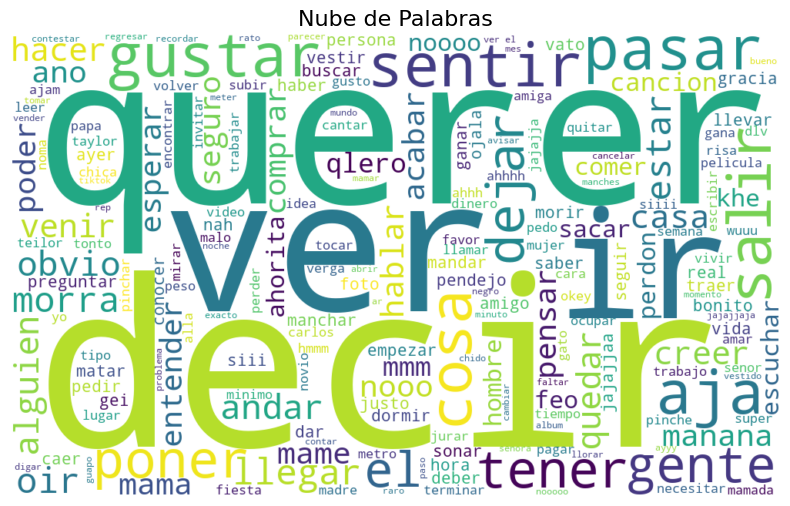

In [36]:
texto_total = " ".join(datos["Texto_limpio"].tolist())

wordcloud = WordCloud(
    width=1000,
    height=600,
    background_color="white",
    max_words=200,
    colormap="viridis"
).generate(texto_total)

plt.figure(figsize=(10,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de Palabras", fontsize=16)
plt.show()


### Modelado

In [65]:
#Variables
X = datos["Texto_limpio"]
y = datos["Emisor"]

In [75]:
#Split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.3, random_state = 1989, stratify = y)

In [76]:
#Vectorizamos
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2), 
    min_df= 0.001,
    max_df=0.7,
    stop_words=None
)

In [78]:
# Ajustamos con el train y transformamos ambos
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [79]:
print(f"Train shape: {X_train_tfidf.shape}")
print(f"Test shape:  {X_test_tfidf.shape}")

Train shape: (44497, 361)
Test shape:  (19071, 361)


### Bayes Classifier

In [86]:
#Función para evaluación del rendimiento
def evaluate_model(model, X, y, dataset_name="Dataset"):
    y_pred_default = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]

    #Métricas con umbral 0.5
    acc = accuracy_score(y, y_pred_default)
    sens = recall_score(y, y_pred_default)
    cm = confusion_matrix(y, y_pred_default)
    spec = cm[0,0] / (cm[0,0] + cm[0,1])
    auc = roc_auc_score(y, y_proba)

    print(f"\n=== Resultados en {dataset_name} (umbral = 0.5) ===")
    print(f"Accuracy:      {acc:.4f}")
    print(f"Sensibilidad:  {sens:.4f}")
    print(f"Especificidad: {spec:.4f}")
    print(f"AUC:           {auc:.4f}")

    #Calibración con J de Youden
    fpr, tpr, thresholds = roc_curve(y, y_proba)
    specificity = 1 - fpr
    J = tpr + specificity - 1
    idx_opt = np.argmax(J)
    best_threshold = thresholds[idx_opt]

    print(f"\n--- Calibración Youden J ---")
    print(f"Umbral óptimo:          {best_threshold:.4f}")
    print(f"Sensibilidad óptima:    {tpr[idx_opt]:.4f}")
    print(f"Especificidad óptima:   {specificity[idx_opt]:.4f}")

    #Recalcular métricas con umbral óptimo
    y_pred_opt = (y_proba >= best_threshold).astype(int)
    acc_opt = accuracy_score(y, y_pred_opt)
    sens_opt = recall_score(y, y_pred_opt)
    cm_opt = confusion_matrix(y, y_pred_opt)
    spec_opt = cm_opt[0,0] / (cm_opt[0,0] + cm_opt[0,1])

    print(f"\n=== Resultados en {dataset_name} (umbral óptimo) ===")
    print(f"Accuracy:      {acc_opt:.4f}")
    print(f"Sensibilidad:  {sens_opt:.4f}")
    print(f"Especificidad: {spec_opt:.4f}")

    #Curva ROC con umbral óptimo
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"{dataset_name} (AUC={auc:.4f})", color='blue')
    plt.plot([0,1], [0,1], "k--")
    plt.scatter(fpr[idx_opt], tpr[idx_opt], color='red', label=f"Umbral óptimo={best_threshold:.3f}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"Curva ROC - {dataset_name}")
    plt.legend()
    plt.show()

In [87]:
#Creamos un grid para el mejor alpha
param_grid = {"alpha": np.logspace(-3, 1, 10)}  # valores desde 0.001 hasta 10
grid = GridSearchCV(MultinomialNB(), param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid.fit(X_train_tfidf, y_train)

GridSearchCV(cv=5, estimator=MultinomialNB(), n_jobs=-1,
             param_grid={'alpha': array([1.00000000e-03, 2.78255940e-03, 7.74263683e-03, 2.15443469e-02,
       5.99484250e-02, 1.66810054e-01, 4.64158883e-01, 1.29154967e+00,
       3.59381366e+00, 1.00000000e+01])},
             scoring='accuracy')

In [88]:
best_alpha = grid.best_params_["alpha"]
print(f"Mejor alfa encontrado: {best_alpha:.4f}")

Mejor alfa encontrado: 3.5938


In [89]:
# Modelo final
nb = MultinomialNB(alpha=best_alpha)
nb.fit(X_train_tfidf, y_train)

MultinomialNB(alpha=np.float64(3.593813663804626))

In [90]:
#Validación cruzada
cv_scores = cross_val_score(nb, X_train_tfidf, y_train, cv=5, scoring="accuracy")
print("\n=== Cross Validation ===")
print(f"Media: {cv_scores.mean():.4f}")
print(f"Mediana: {np.median(cv_scores):.4f}")
print(f"Desviación estándar: {cv_scores.std():.4f}")


=== Cross Validation ===
Media: 0.6077
Mediana: 0.6082
Desviación estándar: 0.0034



=== Resultados en Train (umbral = 0.5) ===
Accuracy:      0.6164
Sensibilidad:  0.3722
Especificidad: 0.8409
AUC:           0.6696

--- Calibración Youden J ---
Umbral óptimo:          0.4799
Sensibilidad óptima:    0.4168
Especificidad óptima:   0.7988

=== Resultados en Train (umbral óptimo) ===
Accuracy:      0.6158
Sensibilidad:  0.4168
Especificidad: 0.7988


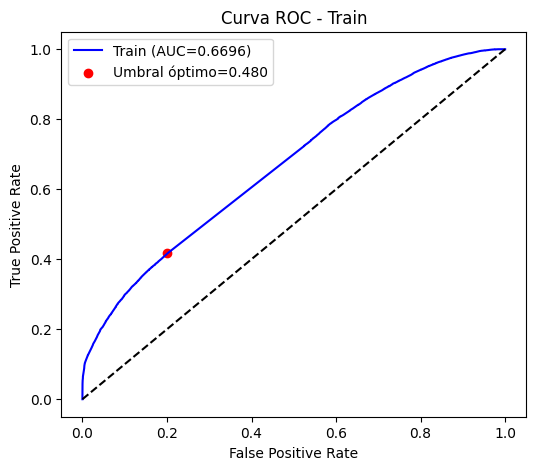


=== Resultados en Test (umbral = 0.5) ===
Accuracy:      0.6098
Sensibilidad:  0.3617
Especificidad: 0.8378
AUC:           0.6573

--- Calibración Youden J ---
Umbral óptimo:          0.5002
Sensibilidad óptima:    0.3617
Especificidad óptima:   0.8380

=== Resultados en Test (umbral óptimo) ===
Accuracy:      0.6099
Sensibilidad:  0.3617
Especificidad: 0.8380


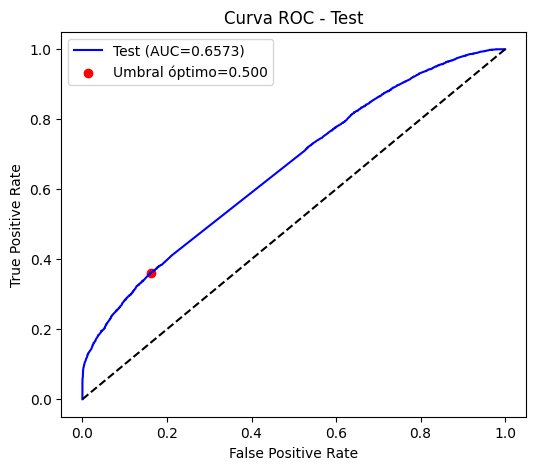

In [91]:
evaluate_model(nb, X_train_tfidf, y_train, "Train")
evaluate_model(nb, X_test_tfidf, y_test, "Test")

#### Regresión logística

In [92]:
#Instanciamos el modelo
log_reg = LogisticRegression(max_iter=5000, penalty = "elasticnet", solver = "saga")

In [95]:
#Mejor parametro C
param_grid_log = {
    "C": np.logspace(-3, 3, 7),  # valores entre 0.001 y 1000
    "l1_ratio": uniform(0, 1)  #valores de 0 a 1
}

In [97]:
#Búsqueda aleatoria
log_search = RandomizedSearchCV(
    estimator=log_reg,
    param_distributions=param_grid_log,
    n_iter=30,
    scoring="accuracy",
    cv=5,
    random_state=1989,
    n_jobs=-1
)

In [98]:
log_search.fit(X_train_tfidf, y_train)

RandomizedSearchCV(cv=5,
                   estimator=LogisticRegression(max_iter=5000,
                                                penalty='elasticnet',
                                                solver='saga'),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'C': array([1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03]),
                                        'l1_ratio': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x00000167259D7590>},
                   random_state=1989, scoring='accuracy')

In [99]:
#Mejores parámetros
best_log = log_search.best_estimator_
print("Mejores parámetros Logistic Regression:", log_search.best_params_)

Mejores parámetros Logistic Regression: {'C': np.float64(0.1), 'l1_ratio': np.float64(0.09307562439911576)}


In [106]:
best_c = log_search.best_params_["C"]
best_l1 = log_search.best_params_["l1_ratio"]

#### Mejores hiperparams

In [107]:
#Mejor modelo
best_reglog = LogisticRegression(max_iter=5000, penalty = "elasticnet", solver = "saga", C = best_c, l1_ratio = best_l1)

In [108]:
best_reglog.fit(X_train_tfidf, y_train)

LogisticRegression(C=np.float64(0.1), l1_ratio=np.float64(0.09307562439911576),
                   max_iter=5000, penalty='elasticnet', solver='saga')

In [109]:
#Validación cruzada
cv_scores = cross_val_score(best_reglog, X_train_tfidf, y_train, cv=5, scoring="accuracy")
print("\n=== Cross Validation ===")
print(f"Media: {cv_scores.mean():.4f}")
print(f"Mediana: {np.median(cv_scores):.4f}")
print(f"Desviación estándar: {cv_scores.std():.4f}")


=== Cross Validation ===
Media: 0.6077
Mediana: 0.6071
Desviación estándar: 0.0035



=== Resultados en Train (umbral = 0.5) ===
Accuracy:      0.6163
Sensibilidad:  0.3715
Especificidad: 0.8414
AUC:           0.6701

--- Calibración Youden J ---
Umbral óptimo:          0.4781
Sensibilidad óptima:    0.4300
Especificidad óptima:   0.7894

=== Resultados en Train (umbral óptimo) ===
Accuracy:      0.6173
Sensibilidad:  0.4300
Especificidad: 0.7894


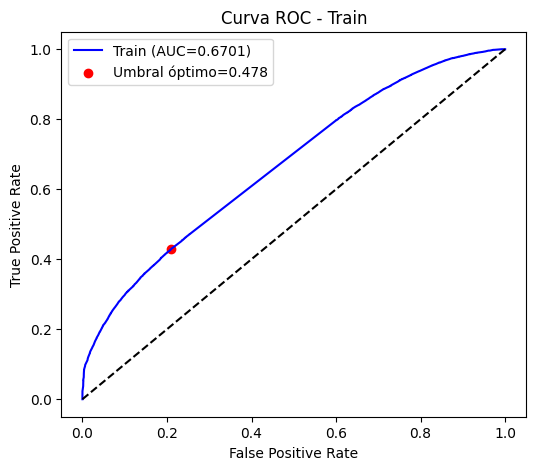


=== Resultados en Test (umbral = 0.5) ===
Accuracy:      0.6089
Sensibilidad:  0.3627
Especificidad: 0.8352
AUC:           0.6560

--- Calibración Youden J ---
Umbral óptimo:          0.4852
Sensibilidad óptima:    0.4023
Especificidad óptima:   0.8023

=== Resultados en Test (umbral óptimo) ===
Accuracy:      0.6107
Sensibilidad:  0.4023
Especificidad: 0.8023


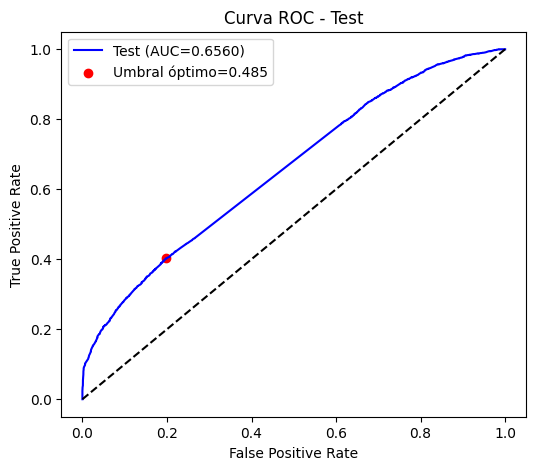

In [110]:
#Evaluación del rendimiento
evaluate_model(best_reglog, X_train_tfidf, y_train, "Train")
evaluate_model(best_reglog, X_test_tfidf, y_test, "Test")

Nos quedamos con regresión logística, pues tiene mejor precisión y sensibilidad.

### Guardamos el mejor modelo

In [111]:
best_reglog.best_threshold_ = 0.4852

In [112]:
def predict_calibrado(model, X):
    proba = model.predict_proba(X)[:, 1]
    return (proba >= model.best_threshold_).astype(int)

In [113]:
y_pred_calibrado = predict_calibrado(best_reglog, X_test_tfidf)

In [114]:
import pickle

modelo_calibrado = {
    "modelo": best_reglog,
    "threshold": 0.4852
}

with open("C:/Users/raulb/Desktop/Diplomado/Modulo2/Datos/best_reglog.pkl", "wb") as f:
    pickle.dump(modelo_calibrado, f)

#### Abrimos

In [115]:
with open("C:/Users/raulb/Desktop/Diplomado/Modulo2/Datos/best_reglog.pkl", "rb") as f:
    data = pickle.load(f)

modelo = data["modelo"]
threshold = data["threshold"]

In [116]:
modelo

LogisticRegression(C=np.float64(0.1), l1_ratio=np.float64(0.09307562439911576),
                   max_iter=5000, penalty='elasticnet', solver='saga')

In [117]:
threshold

0.4852

#### Usamos el modelo 

In [122]:
#Función para recibir un mensaje y predecir quien lo dijo
def predict_msg(text, model, vectorizer, threshold=None):
    # Limpiar texto
    tokens = clean_text(text)
    if not tokens:
        return "Mensaje vacío o sin contenido válido", 0.0
    
    # Convertir tokens a texto (TF-IDF espera texto crudo)
    text_clean = " ".join(tokens)
    
    # Vectorizar
    X_vect = vectorizer.transform([text_clean])
    
    # Obtener probabilidades
    proba = model.predict_proba(X_vect)[0, 1]  # probabilidad de clase positiva
    
    # Determinar umbral de decisión
    if threshold is None:
        threshold = getattr(model, "best_threshold_", 0.5)
    
    # Predicción calibrada
    pred = int(proba >= threshold)
    
    # Asignar emisor
    emisor = "Mariana" if pred == 1 else "Raul"
    
    return emisor, proba

In [164]:
Emisor, prob = predict_msg("porque patria se escribe con a de mujer", modelo, tfidf, threshold)

In [165]:
print(f"Emisor: {Emisor}, probabilidad: {prob}")

Emisor: Raul, probabilidad: 0.322124305073184
